### Imports Necessary Modules

In [ ]:
import os
import glob
import re
import numpy as np
import pandas as pd
from dataclasses import dataclass
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Loading and preparing the IMDB movie review dataset

In [ ]:
# Configuration
@dataclass
class Config:
    MAX_LEN = 256
    BATCH_SIZE = 32
    LR = 0.001
    VOCAB_SIZE = 30000
    EMBED_DIM = 128
    NUM_HEAD = 8
    FF_DIM = 128
    NUM_LAYERS = 1
    
config = Config()

# Download IMDB dataset
if not os.path.exists("aclImdb"):
    !curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz

# Load text data
def get_text_list_from_files(files):
    texts = []
    for file in files:
        with open(file, encoding="utf-8") as f:
            texts += [line.strip() for line in f]
    return texts

def get_data_from_text_files(folder_name):
    pos_files = glob.glob(f"aclImdb/{folder_name}/pos/*.txt")
    neg_files = glob.glob(f"aclImdb/{folder_name}/neg/*.txt")
    pos_texts = get_text_list_from_files(pos_files)
    neg_texts = get_text_list_from_files(neg_files)
    df = pd.DataFrame({
        "review": pos_texts + neg_texts,
        "sentiment": [1]*len(pos_texts) + [0]*len(neg_texts)
    })
    return df.sample(len(df)).reset_index(drop=True)

train_df = get_data_from_text_files("train")
test_df = get_data_from_text_files("test")
all_data = pd.concat([train_df, test_df], ignore_index=True)

print(train_df.head())
print(test_df.head())
print(all_data.sample(5))

                                              review  sentiment
0  There is a DVD published in the UK in 2002 Cod...          0
1  A bit quirky and bordering bad taste; but inte...          1
2  A few years ago, I bought several $1 DVD's tha...          1
3  I haven't laughed that much in a long time - a...          1
4  Sunshine is a European import set in Hungary b...          0
                                              review  sentiment
0  It's certainly a direct-to-video, but the stor...          0
1  This was included on the disk "Shorts: Volume ...          0
2  This film was so bad it became enjoyable. If y...          0
3  A really realistic, sensible movie by Ramgopal...          1
4  This is a decent effort for a B-Movie Martial ...          1
                                                  review  sentiment
4603   I rented this DVD having seen it while looking...          0
46036  I loved this movie! It was adorably touching a...          1
27660  Getting Eaten By A Bu

Head of Dataset:
                                              review  sentiment
0  There is a DVD published in the UK in 2002 Cod...          0
1  A bit quirky and bordering bad taste; but inte...          1
2  A few years ago, I bought several $1 DVD's tha...          1
3  I haven't laughed that much in a long time - a...          1
4  Sunshine is a European import set in Hungary b...          0


/tmp/ipython-input-1066383803.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=all_data, palette="Set2")


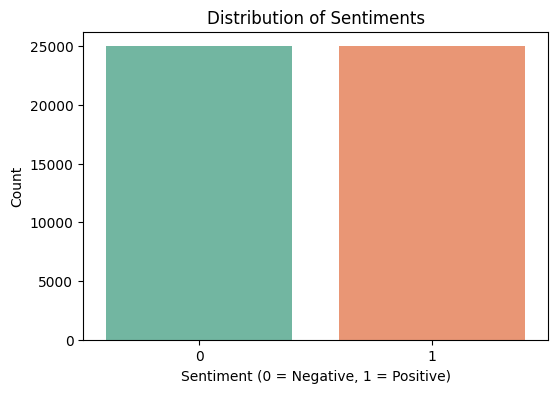

In [ ]:
# Dataset Visualization
print("Head of Dataset:")
print(all_data.head())

# Count of positive vs negative reviews
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=all_data, palette="Set2")
plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()


### Text Vectorization

In [ ]:
def custom_standardization(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, "<br />", " ")
    return tf.strings.regex_replace(text, r"[%s]" % re.escape("!#$%&'()*+,-./:;<=>?@^_`{|}~"), "")

vectorize_layer = layers.TextVectorization(
    max_tokens=config.VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=config.MAX_LEN,
    standardize=custom_standardization
)
vectorize_layer.adapt(all_data.review.values)
mask_token_id = config.VOCAB_SIZE - 1 

def encode(texts):
    return vectorize_layer(tf.convert_to_tensor(texts, dtype=tf.string))


In [ ]:
# Example
texts = ["I love this movie!", "Terrible film."]
encoded = encode(texts)
print(encoded.numpy())


[[ 10 113  11  17   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0 

### Masked LM preparation

In [ ]:
def get_masked_input_and_labels(encoded_texts, mask_prob=0.15):
    encoded_texts = tf.cast(encoded_texts, tf.int64)
    seq_shape = tf.shape(encoded_texts)
    rand_vals = tf.random.uniform(seq_shape)
    inp_mask = tf.logical_and(rand_vals < mask_prob, encoded_texts > 2)

    labels = tf.identity(encoded_texts)
    masked_input = tf.identity(encoded_texts)

    mask_choice = tf.logical_and(inp_mask, tf.random.uniform(seq_shape) < 0.9)
    masked_input = tf.where(mask_choice, mask_token_id, masked_input)

    random_choice = tf.logical_and(mask_choice, tf.random.uniform(seq_shape) < (1/9))
    random_tokens = tf.random.uniform(seq_shape, minval=3, maxval=mask_token_id, dtype=tf.int64)
    masked_input = tf.where(random_choice, random_tokens, masked_input)

    sample_weights = tf.cast(inp_mask, tf.float32)
    return masked_input, labels, sample_weights

x_all_review = encode(all_data.review.values)
x_masked_train, y_masked_labels, sample_weights = get_masked_input_and_labels(x_all_review)
mlm_ds = tf.data.Dataset.from_tensor_slices((x_masked_train, y_masked_labels, sample_weights)).shuffle(1000).batch(config.BATCH_SIZE)


In [ ]:
# Visualization 
sample_texts = all_data.review.values[:1]
encoded = encode(sample_texts)

masked_input, labels, sample_weights = get_masked_input_and_labels(encoded)

masked_input = masked_input.numpy()
labels = labels.numpy()
sample_weights = sample_weights.numpy()

vocab = vectorize_layer.get_vocabulary()

for i in range(1):
    print(f"\n=== Sample {i+1} ===")
    print("Original:", sample_texts[i])

    masked_words = [vocab[id] if sample_weights[i,j]==0 else f"[MASK]" if id==mask_token_id else vocab[id]
                    for j,id in enumerate(masked_input[i]) if id != 0]
    print("Masked input:", " ".join(masked_words))

    label_words = [vocab[id] for j,id in enumerate(labels[i]) if id != 0]
    print("Labels       :", " ".join(label_words))

    print("Weights      :", sample_weights[i][:len(masked_words)])



=== Sample 1 ===
Original: There is a DVD published in the UK in 2002 Code HRGD002 on the cover, no ASIN, VFC 19796 on the disk, no IFPI code in the inner rim.<br /><br />Probably a straight transfer from VHS. <br /><br />There is no much point is commenting an adult film. But this one contains a minimal plot, and the characters are believable. It was shown in the United States in normal cinemas.<br /><br />I've seen it In Pensylvannia way back in 1975.<br /><br />As such it deserves a place in an Encyclopedia of Movies. The DVD has no special features and no subtitles, and was probably made using a VHS tape as source
Masked input: there is a dvd published in the uk in 2002 code [UNK] on the cover no asin [UNK] [UNK] on the disk no [UNK] [MASK] [MASK] the inner [MASK] probably a pseudoscientific transfer from vhs strives is no much point is commenting an [MASK] [MASK] but this one contains a minimal plot and the [MASK] are [MASK] [MASK] was shown in the united [MASK] in [MASK] cinemas

### Positional Embedding

In [ ]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.token_emb(x) + self.pos_emb(positions)


### BERT Module

In [ ]:
def bert_module(query, key, value):
    attention = layers.MultiHeadAttention(num_heads=config.NUM_HEAD, key_dim=config.EMBED_DIM // config.NUM_HEAD)(query, key, value)
    attention = layers.LayerNormalization(epsilon=1e-6)(query + attention)
    ffn = keras.Sequential([layers.Dense(config.FF_DIM, activation="relu"), layers.Dense(config.EMBED_DIM)])
    ffn_output = ffn(attention)
    ffn_output = layers.LayerNormalization(epsilon=1e-6)(attention + ffn_output)
    return ffn_output

# Build MLM Backbone
def build_mlm_backbone():
    inputs = layers.Input(shape=(config.MAX_LEN,), dtype="int64")
    x = PositionalEmbedding(config.MAX_LEN, config.VOCAB_SIZE, config.EMBED_DIM)(inputs)
    for _ in range(config.NUM_LAYERS):
        x = bert_module(x, x, x)
    outputs = layers.Dense(config.VOCAB_SIZE, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="mlm_backbone")

class MaskedLanguageModel(keras.Model):
    def __init__(self, backbone, **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def call(self, x, training=False):
        return self.backbone(x, training=training)

    def train_step(self, data):
        x, y, w = data
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss_per_token = keras.losses.sparse_categorical_crossentropy(y, y_pred)
            weighted_loss = loss_per_token * w
            loss = tf.reduce_sum(weighted_loss) / (tf.reduce_sum(w) + 1e-8)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

backbone = build_mlm_backbone()
print("========== MLM Backbone Summary ==========")
backbone.summary()

mlm_model = MaskedLanguageModel(backbone)
mlm_model.compile(optimizer=keras.optimizers.Adam(config.LR))
history = mlm_model.fit(mlm_ds, epochs=10)

backbone.save("mlm_backbone.keras")


========== MLM Backbone Summary ==========


Model: "mlm_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 256, 128)  │  3,872,768 │ input_layer[0][0] │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 128)  │     33,024 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256,       │  3,870,000 │ layer_normalizat… │
│                     │ 30000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,842,352 (29.92 MB)

 Trainable params: 7,842,352 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 86ms/step - loss: 7.1181
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 87ms/step - loss: 6.3497
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 87ms/step - loss: 6.0024
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 87ms/step - loss: 5.7409
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - loss: 5.5487
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - loss: 5.3927
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - loss: 5.2464
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 87ms/step - loss: 5.1063
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - loss: 4.9693
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - loss: 4.8235


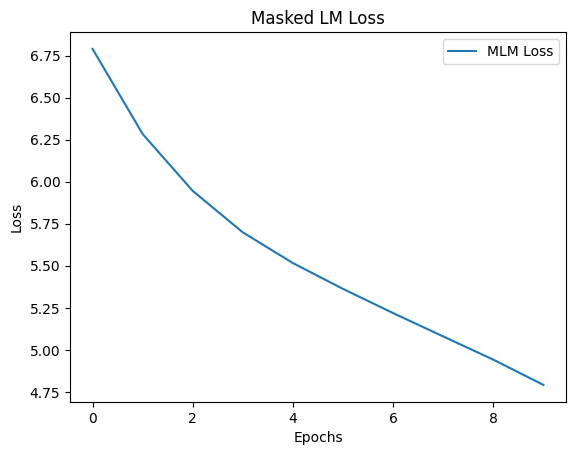

In [ ]:
# Loss for MLM
plt.plot(history.history["loss"], label="MLM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Masked LM Loss")
plt.legend()
plt.show()

### Fine Tuning for Sentiment Classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


========== Classifier Model Summary ==========


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bert_encoder_pre_softmax        │ (None, 256, 128)       │     3,972,352 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,980,673 (15.19 MB)

 Trainable params: 8,321 (32.50 KB)

 Non-trainable params: 3,972,352 (15.15 MB)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.6269 - loss: 0.8510 - val_accuracy: 0.7665 - val_loss: 0.4860
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7730 - loss: 0.4824 - val_accuracy: 0.7454 - val_loss: 0.5248
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7782 - loss: 0.4702 - val_accuracy: 0.7942 - val_loss: 0.4393
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7863 - loss: 0.4539 - val_accuracy: 0.7896 - val_loss: 0.4490
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7845 - loss: 0.4611 - val_accuracy: 0.7906 - val_loss: 0.4442
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7882 - loss: 0.4524 - val_accuracy: 0.7580 - val_loss: 0.5000
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7842 - loss: 0.4602 - val_accuracy: 0.7961 - val_loss: 0.4362
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7873 - loss: 0.4497 - val_acc

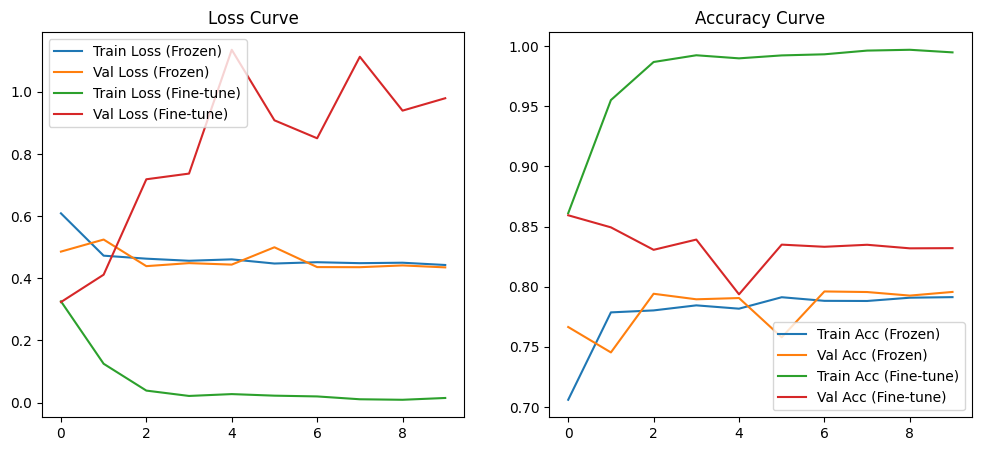

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


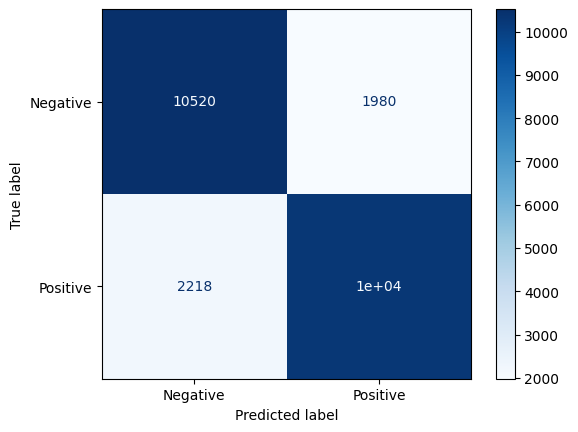

In [ ]:
# Classifier
reloaded_backbone = keras.models.load_model("mlm_backbone.keras", custom_objects={"PositionalEmbedding": PositionalEmbedding})
pre_softmax_tensor = reloaded_backbone.get_layer(index=-1).input
pretrained_bert_model = keras.Model(reloaded_backbone.input, pre_softmax_tensor, name="bert_encoder_pre_softmax")
pretrained_bert_model.trainable = False

def create_classifier_model():
    inputs = layers.Input(shape=(config.MAX_LEN,), dtype="int64")
    x = pretrained_bert_model(inputs)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(), loss="binary_crossentropy", metrics=["accuracy"])
    return model

classifier_model = create_classifier_model()
print("========== Classifier Model Summary ==========")
classifier_model.summary()

x_train = encode(train_df.review.values)
y_train = train_df.sentiment.values
x_test = encode(test_df.review.values)
y_test = test_df.sentiment.values

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1000).batch(config.BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(config.BATCH_SIZE)

# Train classifier (frozen BERT)
history = classifier_model.fit(train_ds, validation_data=test_ds, epochs=10)

# Fine-tune
pretrained_bert_model.trainable = True
classifier_model.compile(optimizer=keras.optimizers.Adam(config.LR), loss="binary_crossentropy", metrics=["accuracy"])
history_ft = classifier_model.fit(train_ds, validation_data=test_ds, epochs=10)

#Visualizations
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss (Frozen)')
plt.plot(history.history['val_loss'], label='Val Loss (Frozen)')
plt.plot(history_ft.history['loss'], label='Train Loss (Fine-tune)')
plt.plot(history_ft.history['val_loss'], label='Val Loss (Fine-tune)')
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc (Frozen)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Frozen)')
plt.plot(history_ft.history['accuracy'], label='Train Acc (Fine-tune)')
plt.plot(history_ft.history['val_accuracy'], label='Val Acc (Fine-tune)')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# Confusion Matrix
y_pred = (classifier_model.predict(test_ds) > 0.5).astype(int).reshape(-1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative","Positive"])
disp.plot(cmap="Blues")
plt.show()


### Comparision with Public Bert Model

Our Model Test Accuracy: 0.8321


Device set to use cuda:0


Public model (DistilBERT SST-2) accuracy: 0.8907


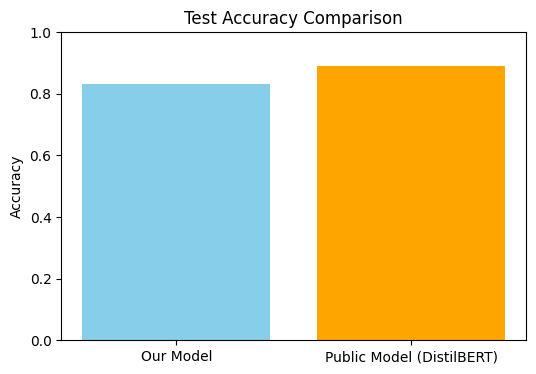

In [ ]:
# Evaluate fine-tuned custom BERT
test_results = classifier_model.evaluate(test_ds, return_dict=True, verbose=0)
print(f"Our Model Test Accuracy: {test_results['accuracy']:.4f}")

# Install transformers for public model
!pip install -q transformers

# Use DistilBERT fine-tuned on SST-2 
public_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    device=0  
)

# Predict on test set
public_predictions = public_classifier(test_df.review.tolist(), truncation=True, max_length=512)

# Map 'POSITIVE' to 1, 'NEGATIVE' to 0 
pred_labels = [1 if p['label'] == 'POSITIVE' else 0 for p in public_predictions]

# Compute accuracy
public_acc = accuracy_score(y_test, pred_labels)
print(f"Public model (DistilBERT SST-2) accuracy: {public_acc:.4f}")


# Visual comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.bar(['Our Model', 'Public Model (DistilBERT)'], [test_results['accuracy'], public_acc], color=['skyblue','orange'])
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()